/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0011 - val_loss: 4.7491e-04
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.1907e-04 - val_loss: 4.8351e-04
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.3854e-04 - val_loss: 5.0507e-04
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.0748e-04 - val_loss: 4.7166e-04
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.7323e-04 - val_loss: 4.8542e-04
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.4368e-04 - val_loss: 4.8198e-04
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.4623e-04 - val_loss: 4.9949e-04
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.4515e-04 - val_loss: 4.5639e-04
Epoch 9/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.3787e-04 - val_loss: 4.7118e-04
Epoch 10/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.3401e-04 - val_loss: 4.5326e-04
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
LSTM RESULTS
RMSE: 0.016149174145994427


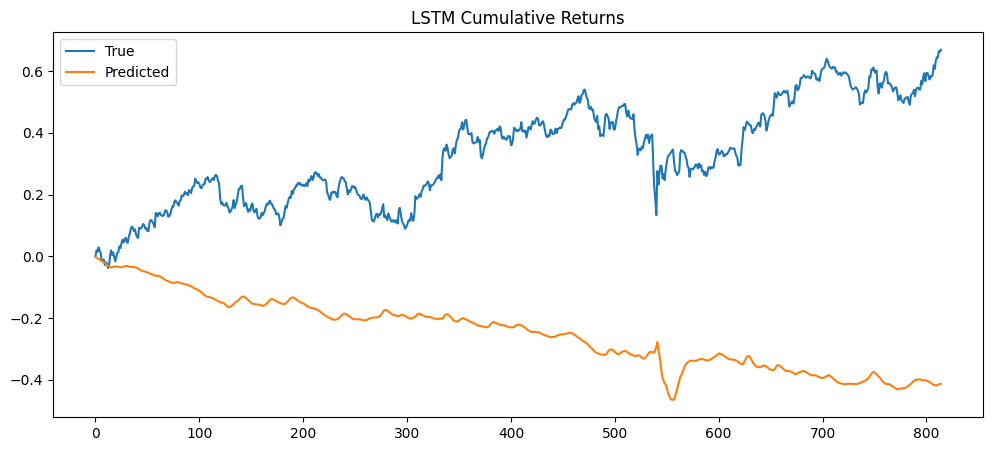

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models

ticker = "AAPL"

raw = yf.download(
    ticker,
    start="2010-01-01",
    progress=False,
    auto_adjust=False,
    threads=False
)

df = pd.DataFrame(index=raw.index)

for col in raw.columns:
    name = str(col).lower()
    if "close" in name:
        df["close"] = raw[col]

df = df.dropna()

df["log_return"] = np.log(df["close"] / df["close"].shift(1))
df["volatility"] = df["log_return"].rolling(20).std()
df["momentum"] = df["close"] / df["close"].shift(10) - 1

df = df.dropna()

y = df["log_return"].values
X = df[["log_return", "volatility", "momentum"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

SEQ_LEN = 20

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y, SEQ_LEN)

split = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

model = models.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, X_seq.shape[2])),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(1)
])

model.compile(optimizer="adam", loss="mse")

model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    verbose=1,
    validation_split=0.1
)

preds = model.predict(X_test).flatten()

rmse = np.sqrt(mean_squared_error(y_test, preds))
direction_acc = np.mean(np.sign(y_test) == np.sign(preds))

print("LSTM RESULTS")
print("RMSE:", rmse)
print("Direction Accuracy:", direction_acc)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(np.cumsum(y_test), label="True")
plt.plot(np.cumsum(preds), label="Predicted")
plt.legend()
plt.title("LSTM Cumulative Returns")
plt.show()